In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.decomposition import PCA


In [3]:
# Load dataset
df = pd.read_csv('creditcard.csv')

In [4]:
# Basic info
print("Shape:", df.shape)


Shape: (284807, 31)


In [5]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [6]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# Class distribution
print("\nClass Distribution:\n", df['Class'].value_counts())



Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
# Percentage
print("\nClass Percentage:\n", df['Class'].value_counts(normalize=True) * 100)


Class Percentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [10]:
# Drop Class for training
X = df.drop('Class', axis=1)

In [11]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

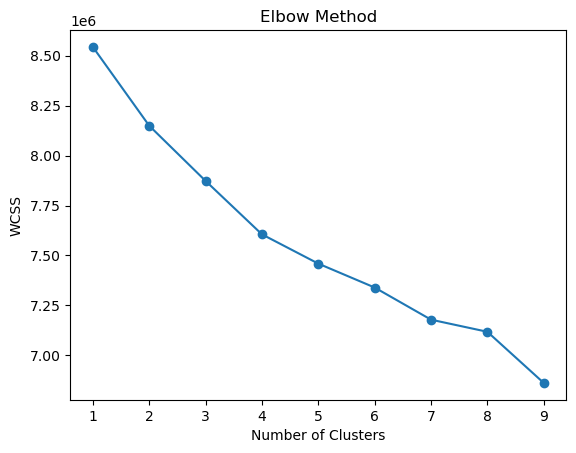

In [14]:
# Elbow Method
wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [15]:
# Train model (choose K=2)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)


KMeans(n_clusters=2, random_state=42)

In [16]:
# Get cluster labels
df['Cluster'] = kmeans.labels_

In [20]:
# Distance from centroid
distances = np.min(kmeans.transform(X_scaled), axis=1)

In [21]:
# Add distance column
df['Distance'] = distances


In [22]:
# Top 1% as anomalies
threshold = np.percentile(distances, 99)

df['Anomaly'] = (df['Distance'] > threshold).astype(int)

In [27]:
y_true = df['Class']
y_pred = df['Anomaly']


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[281757   2558]
 [   201    291]]


In [26]:
# Precision
precision = precision_score(y_true, y_pred)
print("Precision:", precision)


Precision: 0.10214110214110214


In [28]:
# Recall
recall = recall_score(y_true, y_pred)
print("Recall:", recall)

Recall: 0.5914634146341463


In [30]:
# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

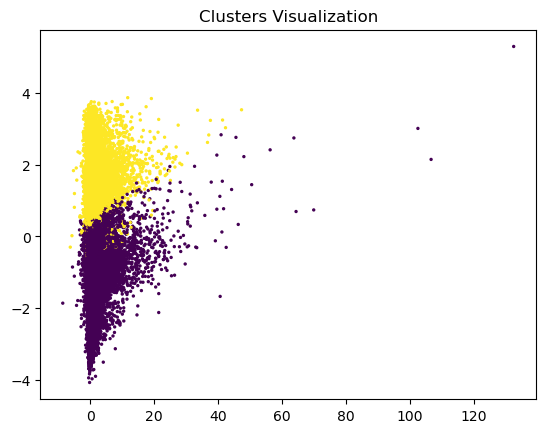

In [33]:
# Plot Clusters
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], s=2)
plt.title('Clusters Visualization')
plt.show()

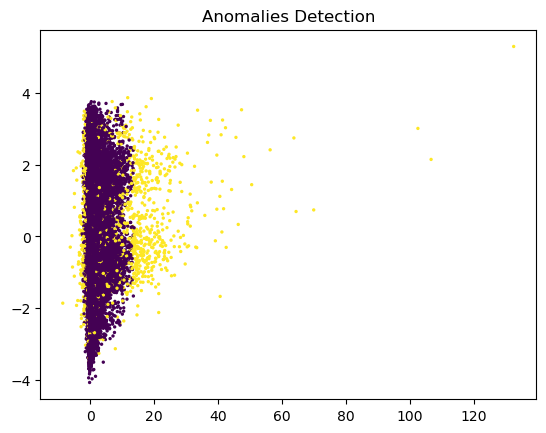

In [32]:
#Plot Anomalies
plt.scatter(df['PCA1'], df['PCA2'], c=df['Anomaly'], s=2)
plt.title('Anomalies Detection')
plt.show()

## Final Summary 
- Dataset is highly imbalanced → fraud is rare
- K-Means clustering used for unsupervised detection
- Distance from centroid used to detect anomalies
- Top 1% transactions treated as fraud candidates
- PCA used for visualization